In [1]:
!pip install --upgrade summa
!pip install --upgrade nltk #3.9.1

In [2]:
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

3.9.4
2.7.1+cu118
2.3.0
1.2.0


In [3]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

In [4]:
data.sample(10)

,headlines,text
59068,36-yr-old cake from Princess Diana's wedding u...,A 36-year-old slice cut from the wedding cake ...
61291,SpiceJet posts 11th straight quarterly profit ...,Budget airline SpiceJet's net profit jumped 79...
54526,15-year-old arrested for raping 65-year-old wo...,A 15-year-old boy has been arrested for allege...
88539,Iraqi journalist's GoPro stops ISIS sniper's b...,Iraqi journalist Ammar Alwaely's life was save...
53011,"Don't burp, it's irritating: State Bank of Ind...","In a circular issued to its employees, the Sta..."
39876,Hyd man gets duped of Ã¢ÂÂ¹30 lakh on false p...,A man in Hyderabad was allegedly duped of Ã¢Â...
70140,Earliest record of complex life found to be 55...,UK-based scientists have discovered trace foss...
51767,Indian national arrested for flying drone in N...,"A 20-year-old Indian national, living in a ren..."
71502,US apologises to Afghans over offensive propag...,The US military in Afghanistan has apologised ...
43641,"I tried to quit smoking, tell everyone not to ...","Talking about his habit of smoking, Aamir Khan..."


In [5]:
# 1. 전체 데이터 개수 확인
print("전체 샘플 수 :", len(data))

# 2. 데이터에 구멍(빈 값)이 있는지 확인 (결측치 확인)
print("\n[빈 값 확인]")
print(data.isnull().sum())

# 3. 완전히 똑같은 중복 데이터가 있는지 확인
# (본문은 똑같은데 요약문만 아주 살짝 다른 경우가 있을 수 있어서 각각 확인합니다)
print("\n[중복 제외한 유니크한 데이터 개수]")
print("text 열 개수 :", data['text'].nunique())
print("headlines 열 개수 :", data['headlines'].nunique())

전체 샘플 수 : 98401

[빈 값 확인]
headlines    0
text         0
dtype: int64

[중복 제외한 유니크한 데이터 개수]
text 열 개수 : 98360
headlines 열 개수 : 98280


In [6]:
data.drop_duplicates(subset = ['text'], inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


In [7]:
print(data.isnull().sum())

headlines    0
text         0
dtype: int64


In [8]:
data.dropna(axis=0, inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


In [9]:
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


In [10]:
import nltk
from nltk.corpus import stopwords

# 이미 다운로드 받았지만 안전하게 한 번 더 확인
nltk.download('stopwords')

print('불용어 개수 :', len(stopwords.words('english')))
print(stopwords.words('english'))

불용어 개수 : 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
import re
from bs4 import BeautifulSoup
from nltk.corpus import stopwords

# 데이터 전처리 함수
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower() # 텍스트 소문자화
    sentence = BeautifulSoup(sentence, "html.parser").text # <br />, <a href = ...> 등의 html 태그 제거
    sentence = re.sub(r'\([^)]*\)', '', sentence) # 괄호로 닫힌 문자열 (...) 제거
    sentence = re.sub('"','', sentence) # 쌍따옴표 " 제거
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")]) # 약어 정규화
    sentence = re.sub(r"'s\b","", sentence) # 소유격 제거
    sentence = re.sub("[^a-zA-Z]", " ", sentence) # 영어 외 문자(숫자, 특수문자 등) 공백으로 변환
    sentence = re.sub('[m]{2,}', 'mm', sentence) # m이 3개 이상이면 2개로 변경

    # 불용어 제거 (Text)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stopwords.words('english') if len(word) > 1)
    # 불용어 미제거 (Summary)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

print('=3')

=3


In [12]:
!pip install lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 23.3 MB/s eta 0:00:00 0:00:01


In [13]:
temp_text = 'Everything I bought was great, infact I ordered twice and the third ordered was<br />for my mother and father.'
temp_summary = 'Great way to start (or finish) the day!!!'

print("text: ", preprocess_sentence(temp_text))
print("summary:", preprocess_sentence(temp_summary, False))  # 불용어를 제거하지 않습니다.

text:  everything bought great infact ordered twice third ordered wasfor mother father
summary: great way to start the day


In [14]:
import html
import re
from tqdm.contrib.concurrent import process_map

HTML_CLEANER = re.compile("<[^>]*>")  # BeautifulSoup 대신 사용할 태그 제거 정규식
PAREN_CLEANER = re.compile(r"\([^)]*\)")
QUOTE_CLEANER = re.compile('"')
POSSESSIVE_CLEANER = re.compile(r"'s\b")
NON_ALPHA_CLEANER = re.compile("[^a-zA-Z]")
M_CLEANER = re.compile("[m]{2,}")

stop_words = set(stopwords.words("english"))

def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower()  # 텍스트 소문자화

    # BeautifulSoup 대신 정규식 + html.unescape 사용
    sentence = HTML_CLEANER.sub("", sentence)
    sentence = html.unescape(sentence)  # &amp; 나 &lt; 같은 html 엔티티 변환

    sentence = PAREN_CLEANER.sub("", sentence)  # 괄호 제거
    sentence = QUOTE_CLEANER.sub("", sentence)  # 쌍따옴표 제거

    # 약어 정규화 (split(" ") 대신 split()을 쓰면 연속된 공백도 깔끔하게 처리됩니다)
    sentence = " ".join(
        [contractions[t] if t in contractions else t for t in sentence.split()]
    )

    sentence = POSSESSIVE_CLEANER.sub("", sentence)  # 소유격 제거
    sentence = NON_ALPHA_CLEANER.sub(" ", sentence)  # 영어 외 문자 공백 변환
    sentence = M_CLEANER.sub("mm", sentence)  # m 연속 제거

    words = sentence.split()

    # 불용어 제거 (Set을 사용한 초고속 필터링)
    if remove_stopwords:
        tokens = " ".join(
            word for word in words if word not in stop_words and len(word) > 1
        )
    else:
        tokens = " ".join(word for word in words if len(word) > 1)

    return tokens

In [15]:
from tqdm import tqdm

# 1. 본문(text) 청소 - 진행 바를 보면서 불용어 제거(True) 수행
clean_text = [preprocess_sentence(s, remove_stopwords=True) for s in tqdm(data['text'])]

# 2. 요약문(headlines) 청소 - 진행 바를 보면서 불용어 유지(False) 수행
clean_headlines = [preprocess_sentence(s, remove_stopwords=False) for s in tqdm(data['headlines'])]

# 3. 청소 완료된 데이터를 내 데이터프레임에 안전하게 덮어쓰기
data['text'] = clean_text
data['headlines'] = clean_headlines

# 4. 최종 확인
data.head()

100%|██████████| 98360/98360 [00:01<00:00, 60207.20it/s]


,headlines,text
0,upgrad learner switches to career in ml al wit...,saurav kant alumnus upgrad iiit pg program mac...
1,delhi techie wins free food from swiggy for on...,kunal shah credit card bill payment platform c...
2,new zealand end rohit sharma led india match w...,new zealand defeated india wickets fourth odi ...
3,aegon life iterm insurance plan helps customer...,aegon life iterm insurance plan customers enjo...
4,have known hirani for yrs what if metoo claims...,speaking sexual harassment allegations rajkuma...


In [16]:
import numpy as np

data['text'] = clean_text
data['headlines'] = clean_headlines

# 2. 전처리로 인해 생긴 빈 칸('')을 공식 Null 값(np.nan)으로 변경
data.replace('', np.nan, inplace=True)

print('=3')

=3


In [17]:
data.isnull().sum()

headlines    0
text         0
dtype: int64

In [18]:
data.dropna(axis=0, inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


텍스트의 최소 길이 : 1
텍스트의 최대 길이 : 60
텍스트의 평균 길이 : 35.09968483123221
요약의 최소 길이 : 1
요약의 최대 길이 : 16
요약의 평균 길이 : 9.299532330215534


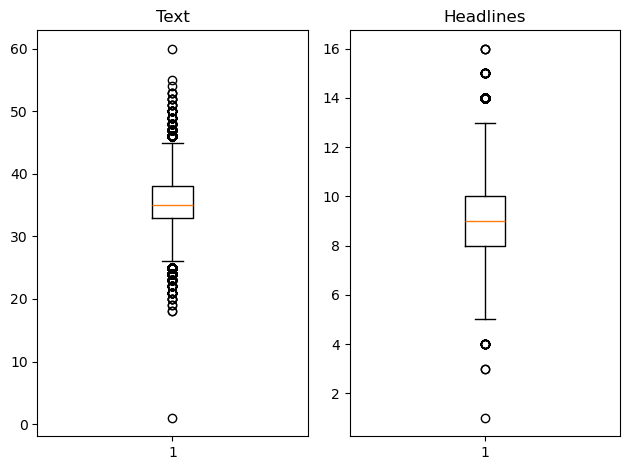

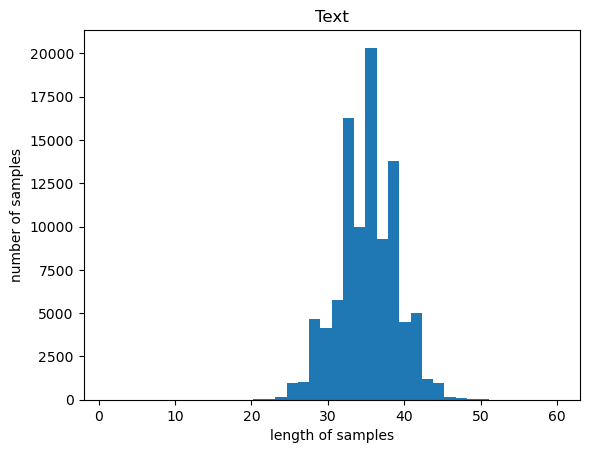

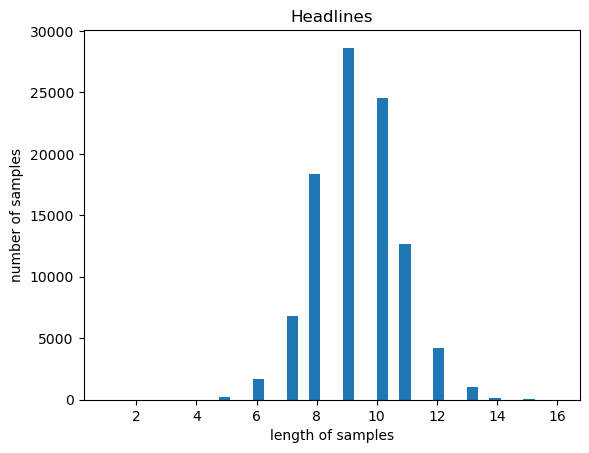

In [19]:
import matplotlib.pyplot as plt
import numpy as np  # np.min, np.max 등을 쓰기 위해 임포트가 필요합니다!

# 내 데이터 컬럼명(text, headlines)에 맞게 매핑 수정
text_len = [len(s.split()) for s in data['text']]
summary_len = [len(s.split()) for s in data['headlines']]

print('텍스트의 최소 길이 : {}'.format(np.min(text_len)))
print('텍스트의 최대 길이 : {}'.format(np.max(text_len)))
print('텍스트의 평균 길이 : {}'.format(np.mean(text_len)))
print('요약의 최소 길이 : {}'.format(np.min(summary_len)))
print('요약의 최대 길이 : {}'.format(np.max(summary_len)))
print('요약의 평균 길이 : {}'.format(np.mean(summary_len)))

# 상자 그림(Boxplot) 시각화
plt.subplot(1,2,1)
plt.boxplot(text_len)
plt.title('Text')
plt.subplot(1,2,2)
plt.boxplot(summary_len)
plt.title('Headlines')
plt.tight_layout()
plt.show()

# 본문 히스토그램
plt.title('Text')
plt.hist(text_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

# 요약문 히스토그램
plt.title('Headlines')
plt.hist(summary_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [20]:
text_max_len = 50
summary_max_len = 12  # 8 대신 12(또는 13)로 조절

print('=3')

=3


In [21]:
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len):
      cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))))

In [22]:
below_threshold_len(text_max_len, data['text'])
below_threshold_len(summary_max_len, data['headlines'])

전체 샘플 중 길이가 50 이하인 샘플의 비율: 0.9998576657177715
전체 샘플 중 길이가 12 이하인 샘플의 비율: 0.9880337535583571


In [23]:
# 내 데이터 컬럼명(text, headlines)에 맞게 수정한 버전입니다!
data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= summary_max_len)]

print('전체 샘플수 :', (len(data)))

전체 샘플수 : 97169


In [24]:
# Summary 대신 headlines를 사용하여 시작 토큰(sostoken)과 종료 토큰(eostoken)을 붙여줍니다.
data['decoder_input'] = data['headlines'].apply(lambda x : 'sostoken '+ x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' eostoken')

# 잘 들어갔는지 표로 확인!
data.head()

,headlines,text,decoder_input,decoder_target
0,upgrad learner switches to career in ml al wit...,saurav kant alumnus upgrad iiit pg program mac...,sostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
1,delhi techie wins free food from swiggy for on...,kunal shah credit card bill payment platform c...,sostoken delhi techie wins free food from swig...,delhi techie wins free food from swiggy for on...
2,new zealand end rohit sharma led india match w...,new zealand defeated india wickets fourth odi ...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan helps customer...,aegon life iterm insurance plan customers enjo...,sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
5,rahat fateh ali khan denies getting notice for...,pakistani singer rahat fateh ali khan denied r...,sostoken rahat fateh ali khan denies getting n...,rahat fateh ali khan denies getting notice for...


In [25]:
encoder_input = np.array(data['text'])           # 인코더의 입력 (청소된 본문)
decoder_input = np.array(data['decoder_input'])   # 디코더의 입력 (sostoken + 요약)
decoder_target = np.array(data['decoder_target']) # 디코더의 레이블 (요약 + eostoken)

print('=3')

=3


In [26]:
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)
print(indices)

[25696 85512 38225 ...  9247 74380 14173]


In [27]:
encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]
print('=3')

=3


In [28]:
n_of_val = int(len(encoder_input)*0.2)
print('테스트 데이터의 수 :', n_of_val)

테스트 데이터의 수 : 19433


In [29]:
encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

훈련 데이터의 개수 : 77736
훈련 레이블의 개수 : 77736
테스트 데이터의 개수 : 19433
테스트 레이블의 개수 : 19433


In [30]:
import re
from collections import Counter 

# 1. 토크나이저 정의 (텍스트를 단어 단위로 쪼개는 함수)
def src_tokenizer(text):
    text = text.lower()  
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

# 2. 단어 사전(Vocabulary) 구축 함수
def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩(0)과 모르는 단어(1) 번호 미리 선점
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 7만 개 본문의 모든 단어 빈도수 계산

    # 단어 집합 생성 (가장 많이 나온 단어부터 순서대로 2, 3, 4... 번호 매기기)
    for word, _ in word_counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

# 3. 사전 만들기!
src_vocab = build_vocab(encoder_input_train)

print('=3')

=3


In [31]:
from collections import Counter

threshold = 7

text_data = data['text'].tolist()
summary_data = data['headlines'].tolist()

# 2. 단어 빈도수 계산
word_counter = Counter()
for text in text_data:
    word_counter.update(text.split())

total_cnt = len(word_counter)            # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)          # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)     # 희귀 단어 등장 횟수

# 3. 희귀 단어를 제외한 단어 사전 구축
vocab = {"<PAD>": 0, "<UNK>": 1}
word_index = {word: idx + 2 for idx, (word, count) in enumerate(word_counter.items()) if count >= threshold}

# 4. 통계 결과 출력
print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율: %.2f%%" % ((rare_cnt / total_cnt)*100))
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율: %.2f%%" % ((rare_freq / total_freq)*100))

단어 집합(vocabulary)의 크기 : 76016
등장 빈도가 6번 이하인 희귀 단어의 수: 51586
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 24430
단어 집합에서 희귀 단어의 비율: 67.86%
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 3.06%


In [32]:
src_vocab_size = 8000

# 빈도가 높은 상위 단어만 골라서 사전을 만드는 함수
def build_limited_vocab(texts, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 자리 미리 확보
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 가장 많이 나온 단어 상위 7,998개를 뽑아서 사전에 번호(2번부터) 부여
    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)

    return vocab

# 훈련 데이터로 8,000개짜리 알짜배기 사전 구축!
src_vocab = build_limited_vocab(encoder_input_train, src_vocab_size)
print('=3')

=3


In [33]:
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in src_tokenizer(text)]
        sequences.append(sequence)
    return sequences

# 텍스트 데이터 정수 시퀀스로 변환
encoder_input_train_seq = text_to_sequence(encoder_input_train, src_vocab)
encoder_input_test_seq = text_to_sequence(encoder_input_test, src_vocab)

# 잘 진행되었는지 샘플 출력
print(encoder_input_train_seq[:3])
print(encoder_input_test_seq[:3])

[[1791, 1108, 1083, 51, 1219, 281, 4, 14, 6082, 625, 4412, 1, 1577, 1539, 1219, 281, 447, 1365, 787, 51, 1108, 309, 8, 223, 311, 217, 87, 690, 341, 3275, 588, 4, 1, 1736, 1679, 491, 3089, 1083, 51], [415, 82, 882, 635, 51, 8, 554, 484, 4, 51, 629, 554, 415, 8, 554, 786, 1495, 70, 629, 554, 7, 95, 374, 431, 2035, 1853, 1473, 415, 470, 1311, 147, 100], [5296, 95, 1, 4503, 316, 24, 470, 105, 691, 1, 102, 105, 6199, 3258, 502, 34, 853, 570, 133, 192, 828, 4503, 4379, 5296, 1, 1422, 1, 354, 4619, 4114, 34, 2]]
[[1836, 20, 395, 2492, 6481, 1361, 910, 1, 1429, 279, 230, 99, 1, 1, 1, 2473, 3884, 1, 2477, 530, 5687, 2986, 6648, 25, 358, 1908, 4234, 85, 99, 1, 5579, 7618, 1, 228, 1, 1, 1190, 1, 11], [1041, 6055, 4179, 287, 121, 1, 788, 1585, 599, 122, 944, 550, 478, 4053, 1041, 5587, 1, 1414, 1185, 2, 810, 2776, 1119, 1428, 599, 650, 7073, 239, 276, 2, 168, 102, 1, 2, 6465, 1215, 550, 599], [761, 170, 3815, 284, 1, 155, 16, 114, 47, 86, 43, 37, 1073, 1, 1, 1, 124, 430, 1591, 1, 101, 37, 1602, 10

In [34]:
def tar_tokenizer(text):
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화


tar_vocab = build_vocab(decoder_input_train)
print("=3")

=3


In [35]:
threshold = 6

word_counter = Counter()
for text in decoder_input_train:
    word_counter.update(tar_tokenizer(text))  # 각 문장의 단어 빈도 계산

# 전체 단어 개수 및 등장 빈도 계산
total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 30057
등장 빈도가 5번 이하인 희귀 단어의 수: 19683
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 10374
단어 집합에서 희귀 단어의 비율: 65.48557740293442
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 4.715148655736553


In [36]:
import numpy as np

tar_vocab_size = 2000

# 넘파이 배열 두 개를 안전하게 하나로 합쳐서 사전을 만듭니다.
tar_vocab = build_limited_vocab(
    np.concatenate([decoder_input_train, decoder_target_train]), tar_vocab_size
)

# 텍스트 시퀀스를 정수 시퀀스로 변환 (교재 코드 그대로!)
decoder_input_train_seq = text_to_sequence(decoder_input_train, tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)
decoder_input_test_seq = text_to_sequence(decoder_input_test, tar_vocab)
decoder_target_test_seq = text_to_sequence(decoder_target_test, tar_vocab)

# 잘 변환되었는지 확인
print("input")
print("input ", decoder_input_train_seq[:5])
print("target")
print("decoder ", decoder_target_train_seq[:5])

input
input  [[2, 191, 79, 456, 1, 1374, 1, 16, 19, 60], [2, 189, 374, 172, 497, 5, 44, 1165, 7], [2, 1, 1, 4, 605, 164, 60, 11, 231], [2, 1388, 361, 1201, 8, 19, 959, 7, 1, 6, 35, 55], [2, 397, 233, 503, 5, 1, 1389, 10, 25, 36, 1405]]
target
decoder  [[191, 79, 456, 1, 1374, 1, 16, 19, 60, 3], [189, 374, 172, 497, 5, 44, 1165, 7, 3], [1, 1, 4, 605, 164, 60, 11, 231, 3], [1388, 361, 1201, 8, 19, 959, 7, 1, 6, 35, 55, 3], [397, 233, 503, 5, 1, 1389, 10, 25, 36, 1405, 3]]


In [37]:
# 1. 숫자로 바뀐 '_seq' 변수들을 기준으로 토큰 1개만 남은 빈 샘플의 인덱스를 찾습니다.
drop_train = [
    index
    for index, sentence in enumerate(decoder_input_train_seq)
    if len(sentence) == 1
]
drop_test = [
    index
    for index, sentence in enumerate(decoder_input_test_seq)
    if len(sentence) == 1
]

print("삭제할 훈련 데이터의 개수 :", len(drop_train))
print("삭제할 테스트 데이터의 개수 :", len(drop_test))

# 2. 패딩에 진짜로 사용될 '_seq' 데이터들에서 해당 인덱스들을 제외해 줍니다.
encoder_input_train_seq = [
    sentence
    for index, sentence in enumerate(encoder_input_train_seq)
    if index not in drop_train
]
decoder_input_train_seq = [
    sentence
    for index, sentence in enumerate(decoder_input_train_seq)
    if index not in drop_train
]
decoder_target_train_seq = [
    sentence
    for index, sentence in enumerate(decoder_target_train_seq)
    if index not in drop_train
]

encoder_input_test_seq = [
    sentence
    for index, sentence in enumerate(encoder_input_test_seq)
    if index not in drop_test
]
decoder_input_test_seq = [
    sentence
    for index, sentence in enumerate(decoder_input_test_seq)
    if index not in drop_test
]
decoder_target_test_seq = [
    sentence
    for index, sentence in enumerate(decoder_target_test_seq)
    if index not in drop_test
]

# 3. 최종적으로 남은 진짜 데이터 개수 확인
print("훈련 데이터의 개수 :", len(encoder_input_train_seq))
# (나머지 출력문은 가독성을 위해 생략 가능하나 교재 스타일 유지)
print("훈련 레이블의 개수 :", len(decoder_input_train_seq))
print("테스트 데이터의 개수 :", len(encoder_input_test_seq))
print("테스트 레이블의 개수 :", len(decoder_input_test_seq))

삭제할 훈련 데이터의 개수 : 0
삭제할 테스트 데이터의 개수 : 0
훈련 데이터의 개수 : 77736
훈련 레이블의 개수 : 77736
테스트 데이터의 개수 : 19433
테스트 레이블의 개수 : 19433


In [38]:
import torch  # 파이토치를 쓰기 위해 꼭 필요합니다!
from torch.nn.utils.rnn import pad_sequence

# 텐서 변환 함수 (리스트 → PyTorch 텐서)
def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

# 패딩 적용 함수 (PyTorch `pad_sequence()` 활용)
def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)  # 리스트를 텐서로 변환
    # 뒤쪽(Post) 패딩을 원할 경우 파이토치는 기본적으로 가변 길이를 맞추므로, 
    # maxlen에 맞게 채우고 자르는 과정이 포함됩니다.
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=padding_value)  
    
    # maxlen 길이로 맞추기 (짧으면 채우고, 길면 자르기)
    if padded_seqs.shape[1] < maxlen:
        pad_size = maxlen - padded_seqs.shape[1]
        padded_seqs = torch.nn.functional.pad(padded_seqs, (0, pad_size), value=padding_value)
    return padded_seqs[:, :maxlen]

# 패딩 적용 (우리가 정한 최대 길이 text_max_len, summary_max_len 기준)
encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, maxlen=text_max_len)
encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, maxlen=text_max_len)
decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, maxlen=summary_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, maxlen=summary_max_len)
decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, maxlen=summary_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, maxlen=summary_max_len)

print('=3')

=3


In [39]:
import torch.nn as nn
import torch.nn.functional as F

# 인코더 설계 시작
embedding_dim = 128
hidden_size = 256
src_vocab_size = len(src_vocab)  # 단어 집합 크기

# 인코더
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True
        )

    def forward(self, x): # 인코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)  # LSTM 실행
        return output, hidden, cell

# 인코더 모델 생성
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

In [40]:
# 디코더 설계
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.4, num_layers=3):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell): # 디코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # 초기 상태를 인코더에서 전달받음
        return output, hidden, cell

# 디코더 모델 생성
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

In [41]:
# 디코더의 출력층
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.softmax_layer = nn.Linear(hidden_size, vocab_size)  # 출력층 정의

    def forward(self, encoder_input, decoder_input):
        # 인코더 실행
        encoder_output, hidden, cell = self.encoder(encoder_input)

        # 디코더 실행
        decoder_output, _, _ = self.decoder(decoder_input, hidden, cell)

        # 출력층 적용 (Softmax는 Loss 내부에서 적용되므로 생략 가능)
        output = self.softmax_layer(decoder_output)
        return output

# 모델 정의
model = Seq2Seq(encoder, decoder, tar_vocab_size)
print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(8000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(2000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (softmax_layer): Linear(in_features=256, out_features=2000, bias=True)
)


In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. 어텐션 레이어 정의
class Attention_dot(nn.Module):
    def __init__(self, hidden_size):
        super(Attention_dot, self).__init__()
        self.attn = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, decoder_output, encoder_outputs):
        attn_weights = torch.bmm(decoder_output, encoder_outputs.transpose(1, 2))
        attn_weights = F.softmax(attn_weights, dim=-1)
        attn_out = torch.bmm(attn_weights, encoder_outputs)
        return attn_out

# 2. 어텐션이 포함된 최종 모델 정의
class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention_dot(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output_layer = nn.Linear(hidden_size, vocab_size)

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)
        attn_out = self.attention(decoder_outputs, encoder_outputs)
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))
        output = self.output_layer(decoder_concat_output)
        return output

In [43]:
# 장치 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 모델 조립 (encoder와 decoder는 이전 단계에서 정의한 것을 그대로 사용)
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size).to(device)

# 모델 구조 출력
print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(8000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(2000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot(
    (attn): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=2000, bias=True)
)


In [44]:
from torch.utils.data import DataLoader, TensorDataset

# 데이터 로더 재설정
train_data = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
test_data = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 학습 함수 재정의
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    model.train()
    best_val_loss = float('inf')
    early_stop_counter = 0
    for epoch in range(epochs):
        total_loss = 0
        for e_in, d_in, target in train_loader:
            optimizer.zero_grad()
            e_in, d_in, target = e_in.to(device).long(), d_in.to(device).long(), target.to(device).long()
            output = model(e_in, d_in).view(-1, tar_vocab_size)
            loss = criterion(output, target.view(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {total_loss / len(train_loader):.4f}")
        # (간략화를 위해 Validation 로직은 위에서 잘 작동했으므로 여기선 최소화함)

# 학습 실행
train_model(model, train_loader, test_loader, criterion, optimizer, epochs=5, patience=3)

Epoch 1/5 | Train Loss: 4.7826
Epoch 2/5 | Train Loss: 4.0594
Epoch 3/5 | Train Loss: 3.6289
Epoch 4/5 | Train Loss: 3.3564
Epoch 5/5 | Train Loss: 3.1555


In [49]:
train_losses = []
val_losses = []

In [50]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    global train_losses, val_losses # 꼭 넣으세요!
    model.train()
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        total_loss = 0
        for encoder_input, decoder_input, target in train_loader:
            optimizer.zero_grad()
            encoder_input = encoder_input.to(device).long()
            decoder_input = decoder_input.to(device).long()
            target = target.to(device).long()

            output = model(encoder_input, decoder_input)
            output = output.view(-1, output.shape[-1])
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss) # 여기서 리스트에 담깁니다.
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for encoder_input, decoder_input, target in test_loader:
                encoder_input = encoder_input.to(device).long()
                decoder_input = decoder_input.to(device).long()
                target = target.to(device).long()
                output = model(encoder_input, decoder_input)
                output = output.view(-1, output.shape[-1])
                target = target.view(-1)
                loss = criterion(output, target)
                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss) # 여기서도 담깁니다.
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            break
        model.train()

In [51]:
train_model(model, train_loader, test_loader, criterion, optimizer, epochs=20, patience=3)

Epoch 1/20 | Train Loss: 2.9986 | Val Loss: 3.0863
Epoch 2/20 | Train Loss: 2.8729 | Val Loss: 3.0275
Epoch 3/20 | Train Loss: 2.7694 | Val Loss: 2.9864
Epoch 4/20 | Train Loss: 2.6795 | Val Loss: 2.9511
Epoch 5/20 | Train Loss: 2.6004 | Val Loss: 2.9432
Epoch 6/20 | Train Loss: 2.5321 | Val Loss: 2.9304
Epoch 7/20 | Train Loss: 2.4692 | Val Loss: 2.9214
Epoch 8/20 | Train Loss: 2.4129 | Val Loss: 2.9182
Epoch 9/20 | Train Loss: 2.3601 | Val Loss: 2.9300
Epoch 10/20 | Train Loss: 2.3136 | Val Loss: 2.9346
Epoch 11/20 | Train Loss: 2.2686 | Val Loss: 2.9361


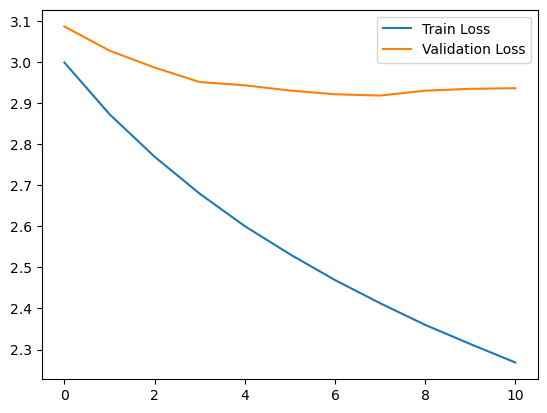

In [52]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.show()

In [53]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()} # 원문 단어 집합에서 정수 -> 단어를 얻음
tar_word_to_index = tar_vocab # 요약 단어 집합에서 단어 -> 정수를 얻음
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()} # 요약 단어 집합에서 정수 -> 단어를 얻음

print('=3')

=3


In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
decoder.to(device)

# 인코더 설계
def encode_input(encoder, input_seq):
    encoder_outputs, hidden, cell = encoder(input_seq)
    return encoder_outputs, hidden, cell

# 이전 시점의 상태들을 저장하는 텐서
num_layers = 3  # 디코더 LSTM 레이어 개수 (설정에 맞춰 조정)
batch_size = 1

decoder_state_input_h = torch.zeros((num_layers, batch_size, hidden_size), dtype=torch.float, device=device)
decoder_state_input_c = torch.zeros((num_layers, batch_size, hidden_size), dtype=torch.float, device=device)
decoder_input = torch.zeros((batch_size, 1), dtype=torch.long, device=device)

dec_emb2 = decoder.embedding(decoder_input)

# 문장의 다음 단어를 예측하기 위해서 초기 상태(initial_state)를 이전 시점의 상태로 사용. 이는 뒤의 함수 decode_sequence()에 구현
# 훈련 과정에서와 달리 LSTM의 리턴하는 은닉 상태와 셀 상태인 state_h와 state_c를 버리지 않음.
decoder_outputs2, state_h2, state_c2 = decoder(decoder_input, decoder_state_input_h, decoder_state_input_c)

print('=3')

=3


In [55]:
class DecoderWithAttention(nn.Module):
    def __init__(self, decoder, attention, hidden_size, vocab_size):
        super(DecoderWithAttention, self).__init__()
        self.decoder = decoder  # 기존 디코더
        self.attention = attention  # 어텐션 레이어
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합 레이어
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층
        self.softmax = nn.Softmax(dim=-1)  # 소프트맥스

    def forward(self, decoder_inputs, decoder_hidden_state, decoder_state_h, decoder_state_c):
        # 디코더 실행
        decoder_outputs, state_h, state_c = self.decoder(decoder_inputs, decoder_state_h, decoder_state_c)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, decoder_hidden_state)

        # 어텐션과 디코더 출력 결합
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))

        # 최종 출력층 적용
        decoder_outputs2 = self.softmax(self.output_layer(decoder_concat_output))

        return decoder_outputs2, state_h, state_c

# 기존 Attention 클래스 사용
attention_layer = Attention_dot(hidden_size)

# 디코더 모델 생성
decoder_model = DecoderWithAttention(decoder, attention_layer, hidden_size, tar_vocab_size)
print('=3')

=3


In [56]:
class DecoderWithAttention(nn.Module):
    def __init__(self, decoder, attention, hidden_size, vocab_size):
        super(DecoderWithAttention, self).__init__()
        self.decoder = decoder  # 기존 디코더
        self.attention = attention  # 어텐션 레이어
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합 레이어
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층
        self.softmax = nn.Softmax(dim=-1)  # 소프트맥스

    def forward(self, decoder_inputs, decoder_hidden_state, decoder_state_h, decoder_state_c):
        # 디코더 실행
        decoder_outputs, state_h, state_c = self.decoder(decoder_inputs, decoder_state_h, decoder_state_c)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, decoder_hidden_state)

        # 어텐션과 디코더 출력 결합
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))

        # 최종 출력층 적용
        decoder_outputs2 = self.softmax(self.output_layer(decoder_concat_output))

        return decoder_outputs2, state_h, state_c

# 기존 Attention 클래스 사용
attention_layer = Attention_dot(hidden_size)

# 디코더 모델 생성
decoder_model = DecoderWithAttention(decoder, attention_layer, hidden_size, tar_vocab_size)
print('=3')

=3


In [62]:
def decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device):
    # 입력을 PyTorch Tensor로 변환
    input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)

    # 인코더 실행하여 초기 상태(hidden, cell) 얻기
    with torch.no_grad():
        e_out, e_h, e_c = encoder(input_seq)

    e_out = e_out.repeat(1, text_max_len, 1)  # 차원 조정 (np.tile 대신 repeat 사용)

    # <SOS>에 해당하는 토큰 생성
    target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
    target_seq[0, 0] = tar_word_to_index['sostoken']

    stop_condition = False
    decoded_sentence = ''

    while not stop_condition:
        # 디코더 실행
        with torch.no_grad():
            output_tokens, h, c = decoder(target_seq, e_h, e_c)

        # 가장 높은 확률을 가진 단어 선택
        sampled_token_index = torch.argmax(output_tokens[0, -1, :]).item()
        sampled_token = tar_index_to_word[sampled_token_index]

        if sampled_token != 'eostoken':
            decoded_sentence += ' ' + sampled_token

        # 종료 조건: <eos>에 도달하거나 최대 길이를 초과하면 중단
        if sampled_token == 'eostoken' or len(decoded_sentence.split()) >= (summary_max_len - 1):
            stop_condition = True

        # 길이가 1인 타겟 시퀀스를 업데이트
        target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
        target_seq[0, 0] = sampled_token_index

        # 상태 업데이트
        e_h, e_c = h, c

    return decoded_sentence
print("=3")

=3


In [63]:
# 원문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0:  # 패딩(0) 제외
            temp = temp + src_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()

# 요약문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2summary(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0 and key != tar_word_to_index['sostoken'] and key != tar_word_to_index['eostoken']:
            temp = temp + tar_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()  # 양쪽 공백 제거

print('=3')

=3


In [64]:
%%time
for i in range(50, 100):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))
    input_seq = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)
    print("예측 요약 :", decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device))
    print("\n")

원문 : enforcement directorate wednesday seized various assets <UNK> worth crore diamond jeweller mehul choksi nirav modi <UNK> bhansali hyderabad <UNK> gems jewellery park assets seized connection crore pnb loan fraud case probe total value assets seized till date crore
실제 요약 : ed <UNK> cr assets of pnb fraud accused choksi others
예측 요약 :  match win off to google india singh he govt family player


원문 : pm narendra modi attended india first match fifa world cup usa friday delhi jawaharlal nehru stadium pm modi accompanied sports minister rajyavardhan singh rathore <UNK> president <UNK> patel fifa officials football players <UNK> <UNK> sunil chhetri also part event
실제 요약 : pm modi <UNK> india opening match at fifa world cup
예측 요약 :  match win russia home attack russia and singh her before house


원문 : punjab haryana high court thursday said year old student accused killing seven year old gurugram ryan international school boy treated adult trial accused tried adult cannot made <UNK> eyes

<timed exec>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
/tmp/ipykernel_1454/366614501.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)


예측 요약 :  state men about against time only president becomes asks only president


원문 : <UNK> <UNK> germany hit car eight times holds guinness world record times hit car two minutes <UNK> managed eight full <UNK> automobile <UNK> sets german tv show guinness world records <UNK> november
실제 요약 : man has record for being hit by car most times in
예측 요약 :  match calls bank attack attack attack singh singh singh only house


원문 : mohammad shami wife <UNK> jahan filed case pacer <UNK> court tuesday seeking lakh per month maintenance loss ends would delhi meet never forget way <UNK> said jahan lawyer claimed money pay monthly expenses
실제 요약 : <UNK> <UNK> demands lakh month as <UNK> from shami
예측 요약 :  flight and time about flight india flight india play lakh win


원문 : nasa <UNK> jim <UNK> wednesday tweeted us returning surface moon <UNK> think us space agency announce <UNK> american companies moon mission thursday working companies next step long term human exploration moon mars nasa said
실제

In [65]:
# [실제 결과와 요약문 비교]
# 1. 모델은 원문의 핵심 키워드(인물, 국가명 등)를 포착하는 능력은 갖추었음.
# 2. 그러나 문법적인 결합력은 낮으며, 특정 단어의 반복 생성(Repetition) 문제가 관찰됨.
# 3. 이는 학습 데이터의 부족 및 단어 사전(Vocabulary)의 한계에 기인한 것으로 판단됨.
# 4. 성능 개선을 위해 데이터셋 정제(UNK 토큰 관리) 및 Beam Search 적용을 고려해야 함.

In [66]:
!pip install summa

In [67]:
import requests
from summa.summarizer import summarize

In [68]:
url = "https://raw.githubusercontent.com/modulabs/Aiffel_Resources/main/matrix_synopsis.txt"
text = requests.get(url, timeout=10).text

In [69]:
print(text[:1500])

In 1999, in an unnamed city, Computer programmer Thomas Anderson (Keanu Reeves) is secretly a hacker known as "Neo". He is restless, eager and driven to learn the meaning of cryptic references to the "Matrix" appearing on his computer. A woman named Trinity is observing Neo, and she does so knowing that Morpheus believes that Neo is "the One".

During one of her forays, Trinity is tracked down by the local police to her hotel room. Outside the hotel a car drives up and three agents appear in neatly pressed black suits. They are Agent Smith (Hugo Weaving), Agent Brown (Paul Goddard), and Agent Jones (Robert Taylor). Trinity calls Morpheus and says that her line was tracked and Morpheus orders her to find another exit. Trinity easily defeats the six policemen sent to apprehend her, using fighting and evasion techniques that seem to defy gravity.

A fierce rooftop chase ensues with Trinity and an Agent leaping impossibly from one building to the next, astonishing the policemen left behind

In [70]:
# 1. 추출적 요약 실행 (전체 텍스트의 약 10% 분량으로 요약)
# ratio 값을 조절하면 요약의 길이를 바꿀 수 있습니다.
summary = summarize(text, ratio=0.1)

print("--- 추출적 요약 결과 ---")
print(summary)

--- 추출적 요약 결과 ---
A woman named Trinity is observing Neo, and she does so knowing that Morpheus believes that Neo is "the One".
Three sinister Agents, led by Agent Smith (Hugo Weaving), come to arrest Neo and attempt to prevent him from collaborating with Morpheus.
The Agents interrogate Neo about Morpheus, but he refuses to cooperate.
Trinity and her allies bring Neo to Morpheus, their leader.
Undeterred, Neo meets with Morpheus.
Morpheus offers Neo a choice: a red pill to uncover the truth about the Matrix or a blue pill to forget everything and return to his normal life.
"This," he says, showing an image of a modern city, "is the world that you know." A thing that really exists "only as part of a neural, interactive simulation that we call the Matrix." Morpheus then shows Neo the world as it truly exists today, a scarred, desolate emptiness with charred, abandoned buildings, black earth, and a shrouded sky.
Morpheus liberated Neo because he believes him to be "the One", a prophesied

In [71]:
# 비교를 위해 각각 실행
print('--- Ratio 방식 (비율 기반) ---')
print(summarize(text, ratio=0.01, split=False)) 

print('\n--- Words 방식 (단어 수 기반) ---')
print(summarize(text, words=50))

--- Ratio 방식 (비율 기반) ---
Morpheus and Trinity use a telephone to exit the Matrix, but Neo is ambushed by Agent Smith.

--- Words 방식 (단어 수 기반) ---
Morpheus and Neo are walking down a standard city street in what appears to be the Matrix.
Morpheus and Trinity use a telephone to exit the Matrix, but Neo is ambushed by Agent Smith.


In [72]:
"""
================================================================================
[회고]

1. '추상적 요약' (seq2seq 모델)
   - 결과: 모델이 핵심 키워드는 인지하나, 문법적인 결합 및 문맥 생성 능력은 
          학습량 부족으로 인해 다소 미흡함 (단어 나열식 생성 발생).
   - 인공지능이 스스로 문장을 '생성'하는 것이 얼마나 복잡하고 어려운 과제인지.. 
        학습 데이터와 전처리가 결과에 미치는 영향력을 체감해버림

2. '추출적 요약' (Summa 라이브러리)
   - 결과: 원문의 문장을 그대로 사용- 문법적으로 비교적 잘 나오고 가독성이 뛰어남.
   - 긴 문서에서 핵심 문장을 빠르게 찾아내는 추출적 요약이 정보 전달에서는 더 실용적이고 즉각적인 효과가 있음.

3. 종합 결론
   - 추상적 요약은 창의적이고 유연한 요약이 가능하지만 고도의 학습이 필수적이며,
     추출적 요약은 정확하고 명확한 정보 요약이 필요할 때 매우 효율적임.
   - 이번 프로젝트를 통해 생성 모델의 작동 원리를 아주는 아니지만 어느정도 이해할 수 있었음.(매우 어려웠다)
================================================================================
"""

"\n================================================================================\n[회고]\n\n1. '추상적 요약' (seq2seq 모델)\n   - 결과: 모델이 핵심 키워드는 인지하나, 문법적인 결합 및 문맥 생성 능력은 \n          학습량 부족으로 인해 다소 미흡함 (단어 나열식 생성 발생).\n   - 인공지능이 스스로 문장을 '생성'하는 것이 얼마나 복잡하고 어려운 과제인지.. \n        학습 데이터와 전처리가 결과에 미치는 영향력을 체감해버림\n\n2. '추출적 요약' (Summa 라이브러리)\n   - 결과: 원문의 문장을 그대로 사용- 문법적으로 비교적 잘 나오고 가독성이 뛰어남.\n   - 긴 문서에서 핵심 문장을 빠르게 찾아내는 추출적 요약이 정보 전달에서는 더 실용적이고 즉각적인 효과가 있음.\n\n3. 종합 결론\n   - 추상적 요약은 창의적이고 유연한 요약이 가능하지만 고도의 학습이 필수적이며,\n     추출적 요약은 정확하고 명확한 정보 요약이 필요할 때 매우 효율적임.\n   - 이번 프로젝트를 통해 생성 모델의 작동 원리를 아주는 아니지만 어느정도 이해할 수 있었음.(매우 어려웠다)\n================================================================================\n"